# Convolution Demo

This notebook will show you the basics how convolution can be used for filtering in 1D and 2D.
We will find out how moving average and gaussian blur can be used efficiently using convolution. Afterwards we will perform simple edge detection on an image.

(author: Jonathan Richter, jonathan.richter@tum.de)

In [1]:
# Import the neccessary libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage

## 1. Generating a test Signal

The following code creates noisey demo data of spiking neurons. The generation of the signal is not neccessarily important to understand, its just for creating some signals to work with for us. Therfore you can skip this section.

In [2]:
##################################################
### Create the signal that you have to extract ###
##################################################

### timing parameters <------------------------------------------------------------------------>
duration,dt,tau = 3000, 1 ,10              
time = np.arange(0, duration, dt)

#--> Spike parameters <------------------------------------------------------------------------>
spike_number = 10
amplitude_range = (0.5, 1.5)

spike_times = np.random.choice(time, spike_number, replace=False)
spike_amplitudes = np.random.uniform(*amplitude_range, spike_number)

#--> Generate calcium trace <------------------------------------------------------------------>
calcium_trace = np.zeros_like(time, dtype=float)
for spike_time, amplitude in zip(spike_times, spike_amplitudes):
    decay = amplitude * np.exp(-(time - spike_time) / tau)
    decay[time < spike_time] = 0  # zero before spike
    calcium_trace += decay

#--> Create the noise to annoy you! <---------------------------------------------------------->
np.random.seed(42)
noise = np.random.rand(duration) * 1.5

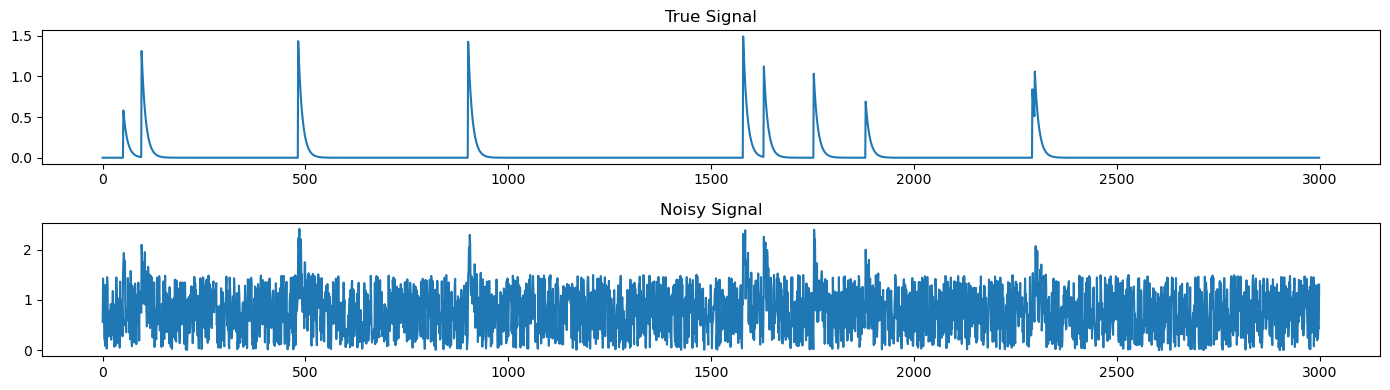

In [3]:
#--> Show the "measured" signal <-------------------------------------------------------------->
signal = noise + calcium_trace

plt.figure(figsize=(14, 4))
plt.subplot(2, 1, 1)  # Top plot
plt.plot(calcium_trace)
plt.title("True Signal")
plt.subplot(2, 1, 2)  # Bottom plot
plt.plot(signal)
plt.title("Noisy Signal")
plt.tight_layout()

## 2. Generate the convolution Kernels
To filter the noise from the noisy signal we will try two different types of kernels, a gauss kernael and a box kernel.

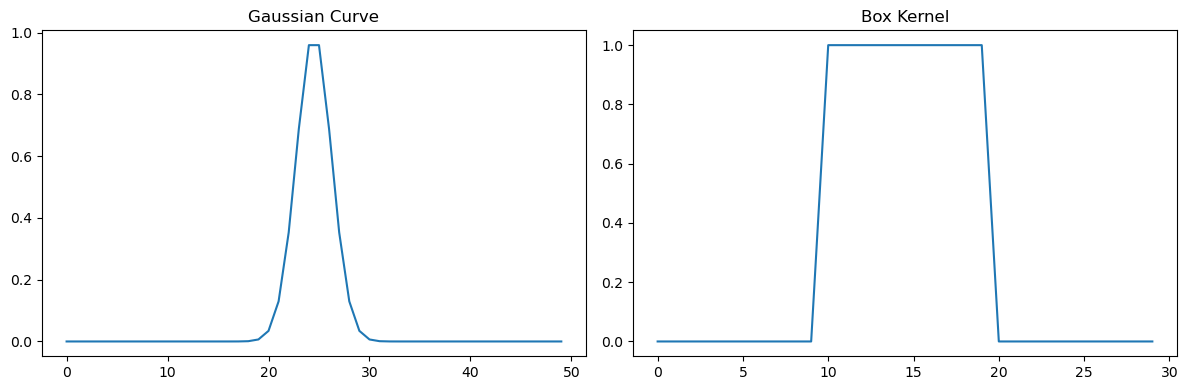

In [4]:
# To create the convolution kernel

def create_gauss_curve(scale):
    gauss_curve = np.exp(-(np.linspace(-5,5,50)*1/scale)**2)
    return gauss_curve

gauss_curve = create_gauss_curve(0.5)
size = 10
box_kernel = np.concatenate([np.zeros(size), np.ones(size), np.zeros(size)])

plt.figure(figsize=(12, 4)) 

# Left subplot
plt.subplot(1, 2, 1)
plt.plot(gauss_curve)
plt.title("Gaussian Curve")

# Right subplot
plt.subplot(1, 2, 2)
plt.plot(box_kernel)
plt.title("Box Kernel")

plt.tight_layout()
plt.show()

## 3. Signal Convolution

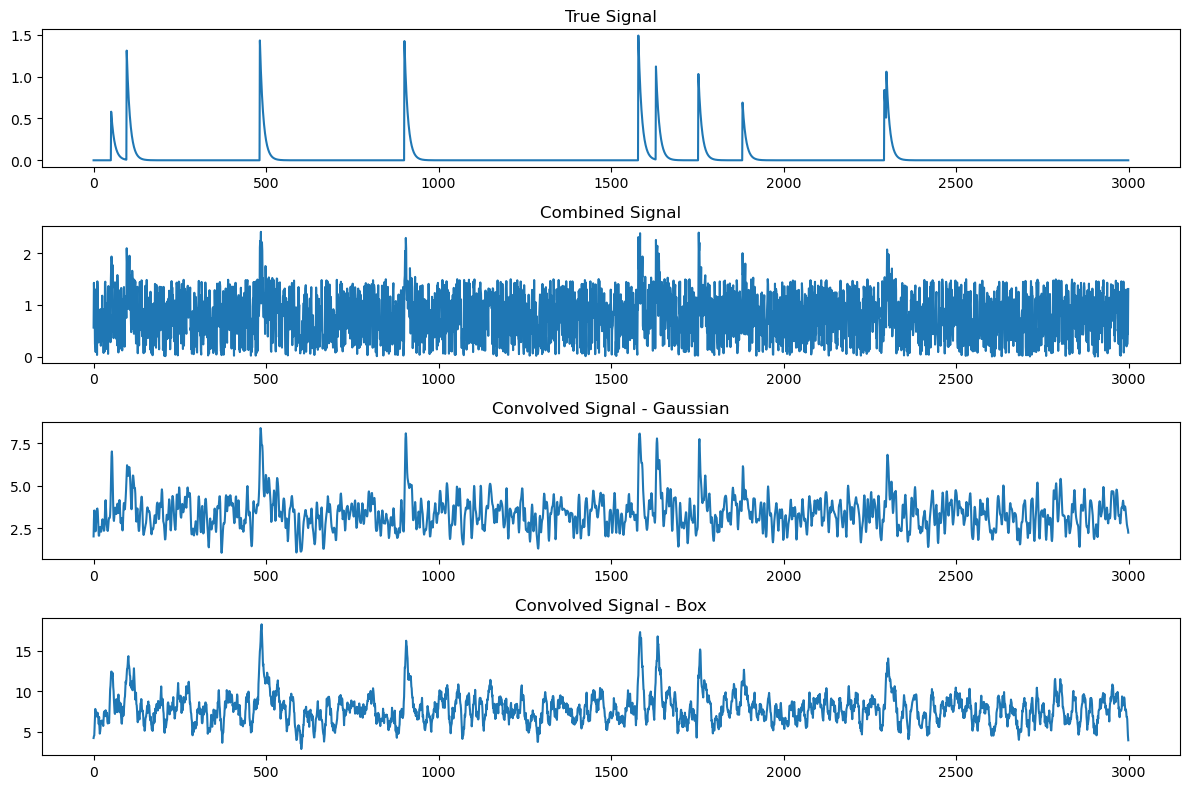

In [5]:
convolution_gauss = np.convolve(signal, gauss_curve, mode='same')
convolution_box = np.convolve(signal, box_kernel, mode='same')


plt.figure(figsize=(12, 8))  # Wider figure for side-by-side plots

# Top subplot
plt.subplot(4, 1, 1)
plt.plot(calcium_trace)
plt.title("True Signal")

# Middle subplot
plt.subplot(4, 1, 2)
plt.plot(signal)
plt.title("Combined Signal")

# Bottom subplot
plt.subplot(4, 1, 3)
plt.plot(convolution_gauss)
plt.title("Convolved Signal - Gaussian")

# Bottom subplot
plt.subplot(4, 1, 4)
plt.plot(convolution_box)
plt.title("Convolved Signal - Box")

plt.tight_layout()

Lets now try to use different kernel sizes!

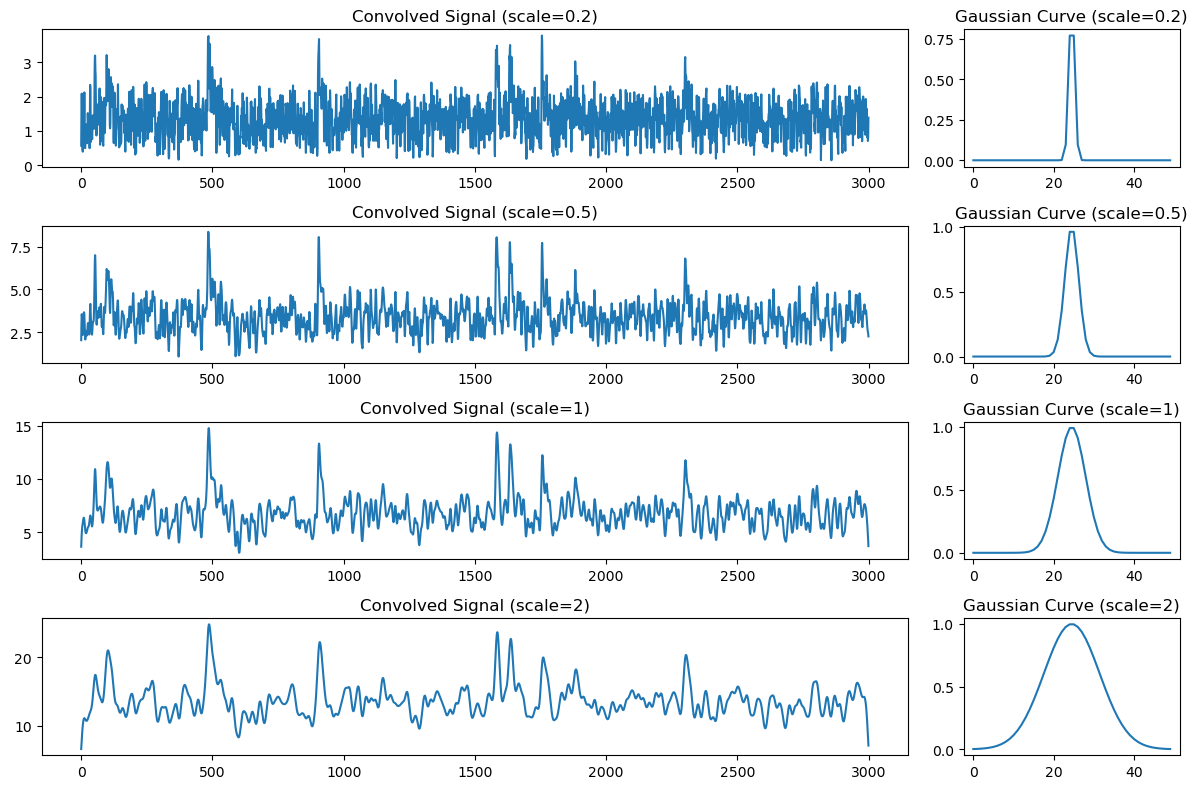

In [6]:
scales = [0.2, 0.5, 1, 2]
num_rows = len(scales)   # Two subplots per scale

# Create all axes at once
fig, axes = plt.subplots(num_rows, 2, figsize=(12, num_rows * 2), gridspec_kw={'width_ratios': [4, 1]})

for i, s in enumerate(scales):
    # Convolve signal with Gaussian
    gauss = create_gauss_curve(s)
    convolution_gauss = np.convolve(signal, gauss, mode='same')

    # Signal plot
    ax_signal = axes[i,0]
    ax_signal.plot(convolution_gauss)
    ax_signal.set_title(f"Convolved Signal (scale={s})")

    # Gaussian curve plot
    ax_gauss = axes[i,1]
    ax_gauss.plot(gauss)
    ax_gauss.set_title(f"Gaussian Curve (scale={s})")

# Tidy up layout
plt.tight_layout()
plt.show()

## 2D Convolution
2D convolution can be interesting to filter noisy images or detect edges and cells. The following code demonstrates some of this concepts.

In [8]:
# Load the Image
image = Image.open("/home/aaa_shared/cshl2025/Data/ConvolutionDemoData/example_convolution.jpg")
image = image.resize((image.width // 16, image.height // 16), Image.Resampling.LANCZOS)
image = np.asarray(image)

## 1. Create different Kernels

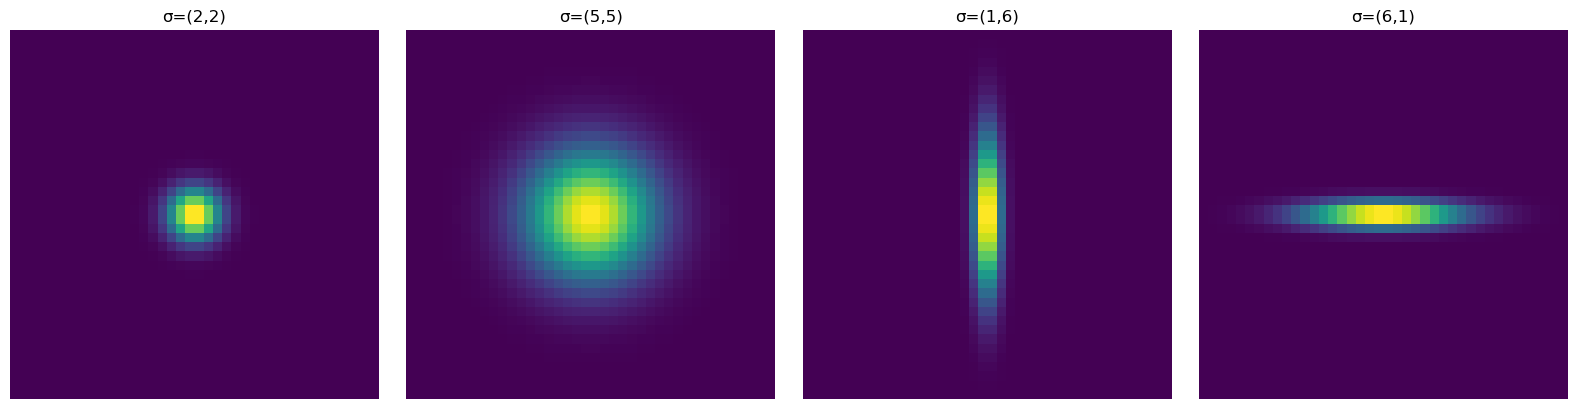

In [9]:
def gaussian_kernel_2d(size_x, size_y, sigma_x, sigma_y):
    x = np.linspace(-size_x // 2, size_x // 2, size_x)
    y = np.linspace(-size_y // 2, size_y // 2, size_y)
    x, y = np.meshgrid(x, y)

    kernel = np.exp(- (x**2 / (2 * sigma_x**2) + y**2 / (2 * sigma_y**2)))
    kernel /= np.sum(kernel)  # Normalize

    return kernel

params = [
    (40, 40, 2, 2),
    (40, 40, 5, 5),
    (40, 40, 1, 6),
    (40, 40, 6, 1)
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

kernels = []
for ax, (sx, sy, sigx, sigy) in zip(axes, params):
    kernel = gaussian_kernel_2d(sx, sy, sigx, sigy)
    kernels.append(kernel)
    im = ax.imshow(kernel, cmap='viridis')
    ax.set_title(f"σ=({sigx},{sigy})")
    ax.axis('off')

kernels = np.asarray(kernels)
plt.tight_layout()
plt.show()

# 2. Blur and Smear Images

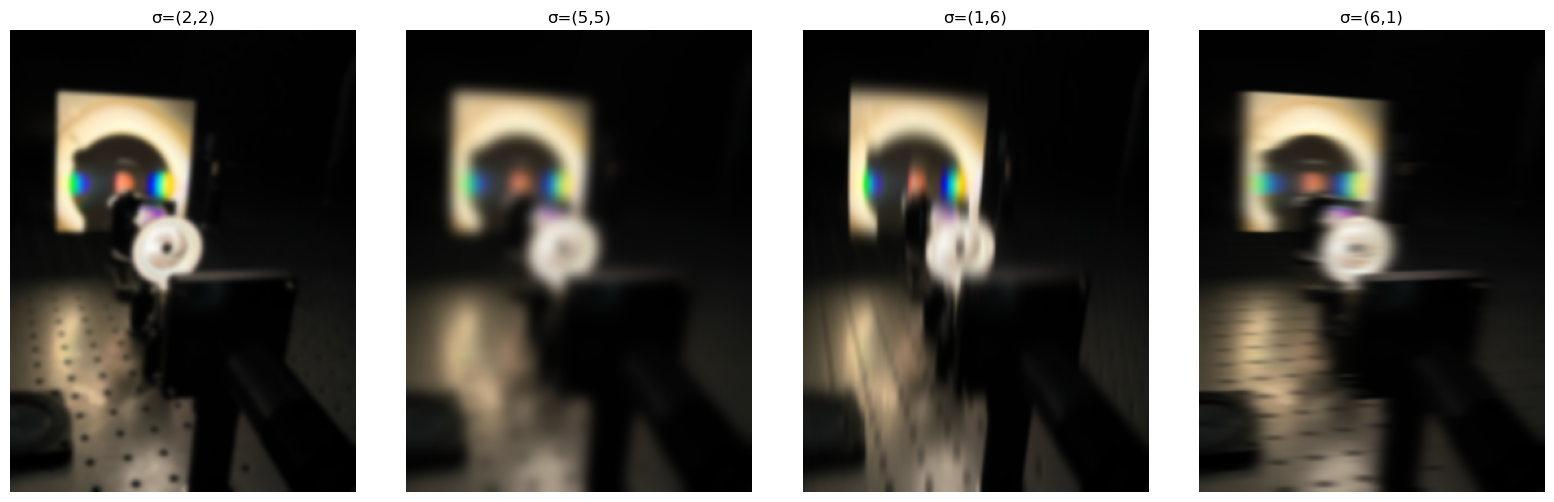

In [10]:
convolved_images = []

for kernel in kernels:
    convolved = np.zeros_like(image)
    for c in range(3):  # R, G, B channels
        convolved[:, :, c] = ndimage.convolve(image[:, :, c], kernel, mode='reflect')
    convolved_images.append(convolved)

# Plot all convolved images side by side
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, img, (_, _, sigx, sigy) in zip(axes, convolved_images, params):
    ax.imshow(img)
    ax.set_title(f"σ=({sigx},{sigy})")
    ax.axis('off')

plt.tight_layout()
plt.show()

# 3. Edge Detection

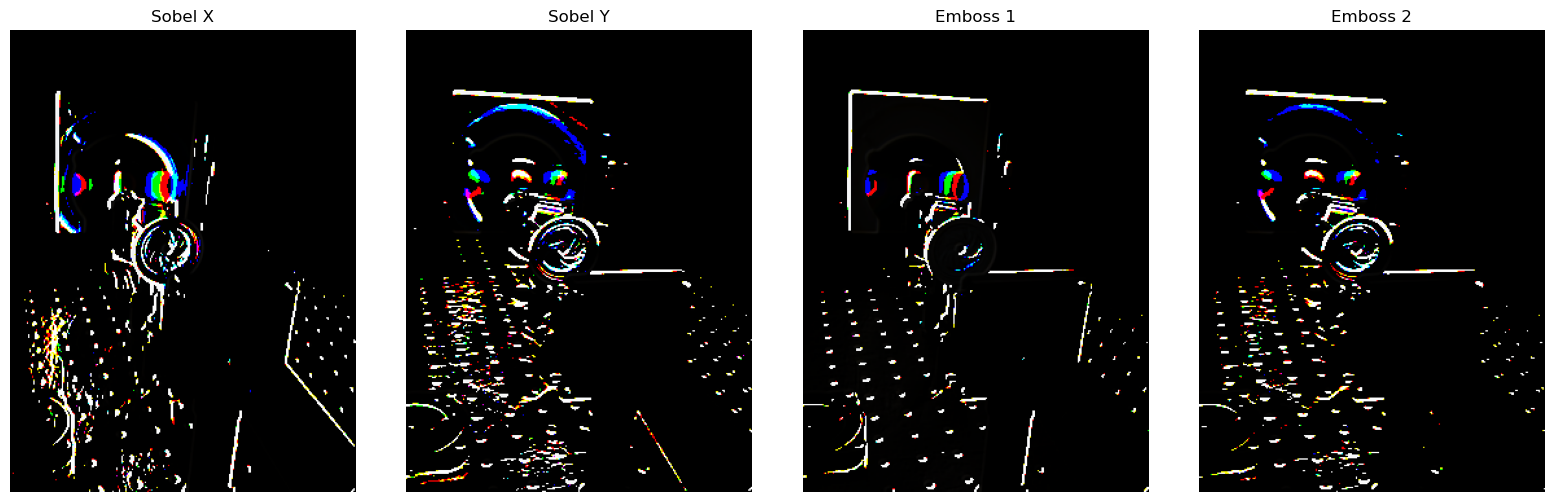

In [11]:
# Define kernels
sobel_x = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1],[ 0,  0,  0],[ 1,  2,  1]])
emboss1 = np.array([[-2, -1,  0],[-1,  1,  1],[ 0,  1,  2]])
emboss2 = np.array([[-1, -1, -1],[ 0,  0,  0],[ 1,  1,  1]])

kernels = [sobel_x*0.02, sobel_y*0.02, emboss1*0.02, emboss2*0.02]
titles = ["Sobel X", "Sobel Y", "Emboss 1", "Emboss 2"]

# Convolve image with each kernel
convolved_images = []

for kernel in kernels:
    convolved = np.zeros_like(image)
    for c in range(3):  # R, G, B channels
        convolved[:, :, c] = ndimage.convolve(image[:, :, c], kernel, mode='reflect')
    convolved_images.append(convolved)

# Plot results side by side
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, img, title in zip(axes, convolved_images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 4. Denoise Images

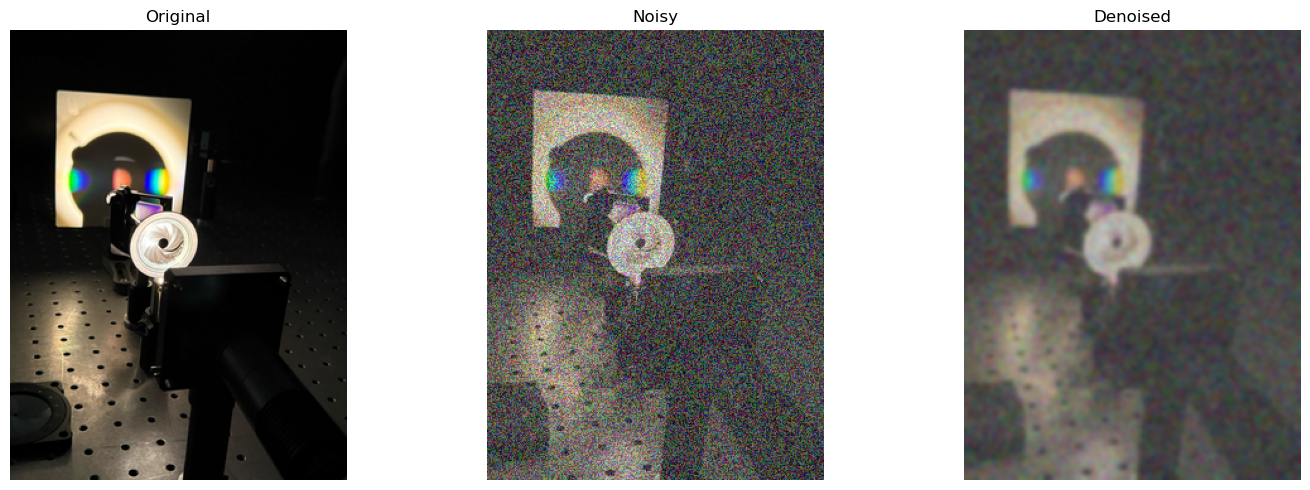

In [12]:
plt.figure(figsize=(15, 5))  # Wider figure for side-by-side layout
noisy_image = ((np.random.rand(*image.shape)*255+image)/np.max((np.random.rand(*image.shape)*255+image))*255).astype(int)
for c in range(3):  # R, G, B channels
     convolved[:, :, c] = ndimage.convolve(noisy_image[:, :, c], gaussian_kernel_2d(40,40,2,2), mode='reflect')

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original")
plt.axis('off')

# Noisy Image
plt.subplot(1, 3, 2)
plt.imshow(noisy_image)
plt.title("Noisy")
plt.axis('off')

# Denoised Image
plt.subplot(1, 3, 3)
plt.imshow(convolved)
plt.title("Denoised")
plt.axis('off')

plt.tight_layout()
plt.show()

# 5. Simple Cell detection

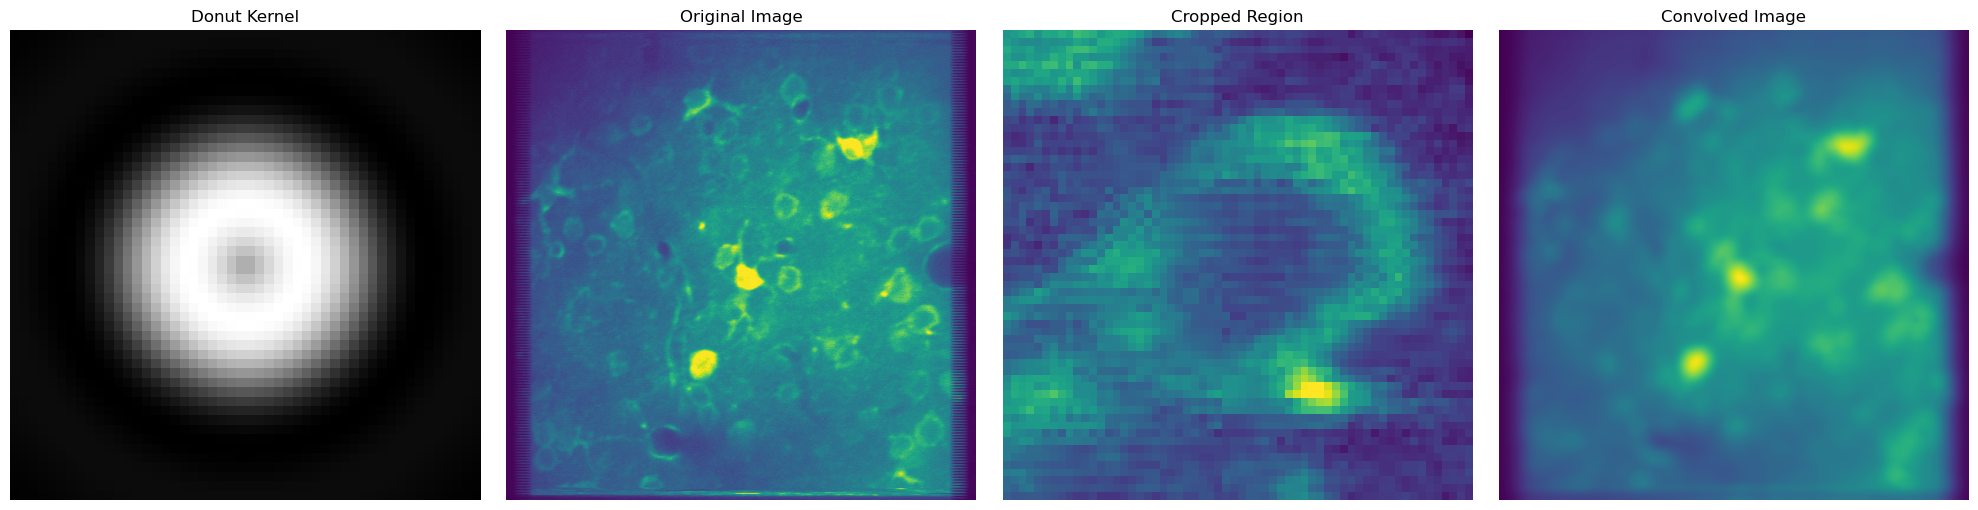

In [13]:
# Create 2D grid
x = np.linspace(-0.5, 0.5, 50)
y = np.linspace(-0.5, 0.5, 50)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# Donut parameters
r_inner = 0.2
r_outer = 0.4
blur_strength = 20
donut = np.exp(-blur_strength * (R - r_inner)**2) * (1 - np.exp(-blur_strength * (R - r_outer)**2))

# Normalize the donut
donut_kernel = donut / np.sum(donut)

# Load image
image = Image.open("/home/aaa_shared/cshl2025/Data/ConvolutionDemoData/convolution_demo_population.jpg")
image = np.asarray(image)
cropped = image[340:400, 500:560]

# Convolve
convolved_image = ndimage.convolve(image, donut_kernel, mode='reflect')

# Plot all side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(donut, cmap='gray')
axes[0].set_title("Donut Kernel")
axes[0].axis('off')

axes[1].imshow(image)
axes[1].set_title("Original Image")
axes[1].axis('off')

axes[2].imshow(cropped)
axes[2].set_title("Cropped Region")
axes[2].axis('off')

axes[3].imshow(convolved_image)
axes[3].set_title("Convolved Image")
axes[3].axis('off')

plt.tight_layout()